# Klasifikasi Kelayakan Kapal Penangkap Ikan
## Menggunakan Histogram of Oriented Gradients (HOG) dan Support Vector Machine (SVM)

Penelitian ini bertujuan mengklasifikasikan kondisi fisik lambung kapal penangkap ikan ke dalam dua kategori, yaitu **Baik** dan **Rusak**, menggunakan metode ekstraksi fitur HOG yang dikombinasikan dengan algoritma klasifikasi SVM. Output akhir adalah model terlatih (`.pkl`) yang dapat diintegrasikan langsung ke dalam sistem aplikasi web.

---


## 1. Import Library

Library yang digunakan dalam penelitian ini beserta fungsinya masing-masing:

| Library | Fungsi |
|---|---|
| `numpy`, `pandas` | Operasi numerik dan pengelolaan data tabular |
| `opencv-python` (`cv2`) | Pembacaan dan konversi format citra digital |
| `skimage.feature.hog` | Implementasi algoritma HOG (Dalal & Triggs, 2005) |
| `sklearn.svm.SVC` | Implementasi SVM dengan dukungan berbagai fungsi kernel |
| `sklearn.model_selection` | GridSearchCV untuk tuning hyperparameter, train_test_split untuk pembagian data |
| `sklearn.preprocessing` | StandardScaler untuk normalisasi fitur |
| `sklearn.metrics` | Fungsi evaluasi: confusion matrix, accuracy, precision, recall, F1 |
| `matplotlib`, `seaborn` | Pembuatan grafik dan visualisasi confusion matrix |
| `joblib` | Penyimpanan dan pemuatan model serta scaler dalam format `.pkl` |


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Direktori penyimpanan file hasil eksperimen
OUTPUT_DIR = 'eksperimen_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('models', exist_ok=True)

np.random.seed(42)


## 2. Load Dataset

Dataset disusun menggunakan struktur folder berbasis label sebagai berikut:

```
dataset/
├── baik/      ->  label 1  (kondisi lambung baik)
└── rusak/     ->  label 0  (kondisi lambung rusak/mengalami kerusakan)
```

Format gambar yang didukung: `.jpg`, `.jpeg`, `.png`.

Pemberian label dilakukan secara otomatis berdasarkan nama folder induk masing-masing gambar.


In [ ]:
DATASET_PATH = 'dataset'
CATEGORIES   = ['baik', 'rusak']

def load_data(dataset_path, categories):
    image_paths, labels = [], []
    for category in categories:
        folder_path = os.path.join(dataset_path, category)
        label = 1 if category == 'baik' else 0
        if not os.path.exists(folder_path):
            print(f"Folder tidak ditemukan: {folder_path}")
            continue
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(folder_path, filename))
                labels.append(label)
    return image_paths, labels

image_paths, labels = load_data(DATASET_PATH, CATEGORIES)

df_dataset = pd.DataFrame({
    'file_path': image_paths,
    'label'    : labels,
    'category' : ['baik' if l == 1 else 'rusak' for l in labels]
})

print(f"Total gambar: {len(df_dataset)}")
print(f"Distribusi kelas:")
print(df_dataset['category'].value_counts().to_string())

if len(df_dataset) == 0:
    raise RuntimeError(
        "Dataset kosong. Pastikan folder dataset/baik/ dan dataset/rusak/ "
        "telah berisi gambar sebelum menjalankan notebook ini."
    )

csv_inventory = os.path.join(OUTPUT_DIR, 'dataset_inventory.csv')
df_dataset.to_csv(csv_inventory, index=False)

display(df_dataset.head())


## 3. Pra-pemrosesan Citra

Sebelum ekstraksi fitur dilakukan, gambar warna tiga-kanal (RGB) dikonversi ke citra skala keabuan (*grayscale*). Konversi ini dilakukan agar algoritma HOG hanya menghitung gradien berdasarkan intensitas cahaya, bukan informasi warna yang tidak relevan untuk deteksi bentuk dan tepi.

Konversi ke grayscale menggunakan pembobotan luminansi standar:

$$I_{\text{gray}}(x, y) = 0.2989 \cdot R + 0.5870 \cdot G + 0.1140 \cdot B$$

Seluruh citra kemudian di-*resize* ke dimensi **128 × 128 piksel** untuk memastikan vektor fitur yang dihasilkan memiliki panjang yang seragam pada setiap sampel.


In [ ]:
IMG_SIZE = (128, 128)

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")
    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    img_gray    = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    return img_rgb, img_gray

# Visualisasi hasil preprocessing pada satu sampel
sample_rgb, sample_gray = preprocess_image(image_paths[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_rgb)
axes[0].set_title("Citra RGB (setelah resize)")
axes[0].axis('off')
axes[1].imshow(sample_gray, cmap='gray')
axes[1].set_title("Citra Grayscale")
axes[1].axis('off')
plt.suptitle("Hasil Pra-pemrosesan Citra", fontsize=12)
plt.tight_layout()
plt.show()


## 4. Ekstraksi Fitur HOG (Histogram of Oriented Gradients)

### Landasan Teori

Metode HOG dikembangkan oleh Dalal dan Triggs (2005) untuk mendeskripsikan penampilan dan bentuk lokal objek melalui distribusi orientasi gradien intensitas piksel. Proses ekstraksi HOG terdiri atas tiga tahap utama:

**Tahap 1: Kalkulasi Gradien**

Gradien dihitung pada setiap piksel menggunakan operator diferensial:

$$G_x(x,y) = I(x+1,\,y) - I(x-1,\,y)$$
$$G_y(x,y) = I(x,\,y+1) - I(x,\,y-1)$$

Magnitudo dan orientasi gradien diperoleh dari:

$$m(x,y) = \sqrt{G_x^2 + G_y^2}$$
$$\theta(x,y) = \arctan\!\left(\frac{G_y}{G_x}\right)$$

**Tahap 2: Histogram per Cell**

Citra dibagi ke dalam blok kecil yang disebut *cell*. Setiap piksel dalam sebuah cell menyumbangkan magnitudonya ke dalam salah satu *bin* histogram sesuai orientasinya. Penelitian ini menggunakan 9 bin orientasi ($0°$–$180°$).

**Tahap 3: Normalisasi Blok (L2-Hys)**

Beberapa cell dikelompokkan menjadi sebuah *block*. Histogram dalam satu block dinormalisasi untuk mengatasi variasi pencahayaan:

$$v_{\text{norm}} = \frac{v}{\sqrt{\|v\|_2^2 + \epsilon^2}}$$

### Parameter Ekstraksi

| Parameter | Nilai |
|---|---|
| `orientations` | 9 |
| `pixels_per_cell` | (8, 8) |
| `cells_per_block` | (2, 2) |
| `block_norm` | L2-Hys |
| `transform_sqrt` | True |

Parameter di atas identik dengan konfigurasi yang digunakan pada modul `hog_extractor.py` di sistem aplikasi web.


In [ ]:
HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM      = 'L2-Hys'

def extract_hog_features(img_gray):
    features = hog(
        img_gray,
        orientations    = HOG_ORIENTATIONS,
        pixels_per_cell = HOG_PIXELS_PER_CELL,
        cells_per_block = HOG_CELLS_PER_BLOCK,
        block_norm      = HOG_BLOCK_NORM,
        transform_sqrt  = True,
        visualize       = False
    )
    return features

# Visualisasi HOG pada gambar sampel
hog_feats, hog_img = hog(
    sample_gray,
    orientations    = HOG_ORIENTATIONS,
    pixels_per_cell = HOG_PIXELS_PER_CELL,
    cells_per_block = HOG_CELLS_PER_BLOCK,
    block_norm      = HOG_BLOCK_NORM,
    transform_sqrt  = True,
    visualize       = True
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title("Citra Grayscale")
axes[0].axis('off')
axes[1].imshow(hog_img, cmap='gray')
axes[1].set_title("Visualisasi HOG")
axes[1].axis('off')
plt.suptitle("Representasi Fitur HOG", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Dimensi vektor fitur HOG per gambar: {hog_feats.shape[0]} elemen")


## 5. Pembentukan Dataset Fitur

Setiap gambar diproses melalui tahap preprocessing dan ekstraksi HOG, kemudian hasilnya diakumulasi menjadi:
- Matriks fitur $\mathbf{X}$: baris mewakili satu sampel, kolom mewakili satu elemen vektor HOG.
- Vektor label $\mathbf{y}$: nilai 1 untuk kelas *Baik*, nilai 0 untuk kelas *Rusak*.

Hasil ekstraksi fitur seluruh sampel disimpan ke file CSV untuk keperluan reproduksibilitas eksperimen.


Berhasil diproses: 342 gambar | Gagal: 0 gambar
Dimensi matriks fitur X: (342, 8100)  (jumlah sampel x jumlah fitur HOG)

Distribusi kelas:
category
baik     203
rusak    139


C:\Users\Husein\AppData\Local\Temp\ipykernel_33772\4054389045.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df_features, palette='viridis', order=['baik','rusak'])


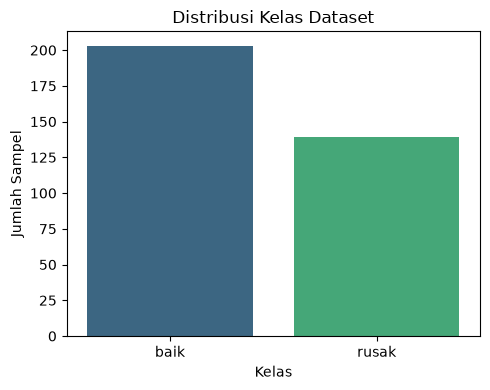


File tersimpan: eksperimen_outputs\feature_extraction_log.csv


,file_path,label,category
0,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
1,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
2,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
3,dataset\baik\WhatsApp Image 2026-06-14 at 1.08...,1,baik
4,dataset\baik\WhatsApp Image 2026-06-14 at 1.10...,1,baik


In [5]:
X, y, valid_paths = [], [], []

print("Proses ekstraksi fitur HOG...")
failed = 0
for path, label in zip(df_dataset['file_path'], df_dataset['label']):
    try:
        _, img_gray = preprocess_image(path)
        feats = extract_hog_features(img_gray)
        X.append(feats)
        y.append(label)
        valid_paths.append(path)
    except Exception as e:
        failed += 1

X = np.array(X)
y = np.array(y)

print(f"Berhasil diproses: {len(X)} gambar | Gagal: {failed} gambar")
print(f"Dimensi matriks fitur X: {X.shape}  (jumlah sampel x jumlah fitur HOG)")

feature_cols = [f'hog_{i}' for i in range(X.shape[1])]
df_features  = pd.DataFrame(X, columns=feature_cols)
df_features.insert(0, 'file_path', valid_paths)
df_features.insert(1, 'label',     y)
df_features.insert(2, 'category',  ['baik' if l == 1 else 'rusak' for l in y])

print("\nDistribusi kelas:")
print(df_features['category'].value_counts().to_string())

plt.figure(figsize=(5, 4))
sns.countplot(x='category', data=df_features, palette='viridis', order=['baik','rusak'])
plt.title("Distribusi Kelas Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")
plt.tight_layout()
plt.show()

csv_feats = os.path.join(OUTPUT_DIR, 'feature_extraction_log.csv')
df_features.to_csv(csv_feats, index=False)
print(f"\nFile tersimpan: {csv_feats}")

display(df_features[['file_path', 'label', 'category']].head())


## 6. Pembagian Data (Train-Test Split)

Dataset dibagi menjadi dua himpunan:
- **Data latih (training set)**: digunakan untuk melatih model.
- **Data uji (testing set)**: digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat.

Pembagian dilakukan dengan rasio **80% training dan 20% testing**, menggunakan metode *stratified sampling* agar proporsi kelas di kedua himpunan tetap seimbang.

Nilai `random_state = 42` digunakan untuk memastikan hasil pembagian dapat direproduksi.


In [6]:
X_feats = df_features[feature_cols].values
y_all   = df_features['label'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_feats, y_all, df_features.index,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_all
)

print(f"Data training: {len(X_train)} sampel")
print(f"Data testing : {len(X_test)} sampel")

df_splits = pd.DataFrame({
    'file_path': df_features.loc[np.concatenate([idx_train, idx_test]), 'file_path'].values,
    'label'    : np.concatenate([y_train, y_test]),
    'set'      : ['train'] * len(idx_train) + ['test'] * len(idx_test)
})
csv_splits = os.path.join(OUTPUT_DIR, 'train_test_split_log.csv')
df_splits.to_csv(csv_splits, index=False)


Data training: 273 sampel
Data testing : 69 sampel


## 7. Normalisasi Fitur (Z-Score Standardization)

SVM menggunakan perhitungan jarak antar vektor fitur dalam menentukan *hyperplane* optimal. Fitur dengan rentang nilai yang besar akan mendominasi perhitungan dan menimbulkan bias pada model. Oleh karena itu, normalisasi fitur diperlukan sebelum pelatihan.

Metode yang digunakan adalah **Z-Score Standardization** (*StandardScaler*), yang mentransformasi setiap fitur sehingga memiliki rata-rata $\mu = 0$ dan standar deviasi $\sigma = 1$:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:
- $x$ : nilai fitur asli
- $\mu$ : rata-rata fitur dihitung dari data training
- $\sigma$ : standar deviasi fitur dihitung dari data training

Parameter $\mu$ dan $\sigma$ hanya di-*fit* dari data training, kemudian diterapkan (*transform*) secara konsisten ke data testing dan ke gambar baru yang diklasifikasikan oleh aplikasi web. Hal ini penting untuk mencegah *data leakage*. Scaler disimpan ke `models/scaler.pkl` agar dapat digunakan kembali saat deployment.


In [7]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaler_path = 'models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler tersimpan: {scaler_path}")


Scaler tersimpan: models/scaler.pkl


## 8. Pelatihan Model SVM

### Dasar Teori

Support Vector Machine (SVM) bekerja dengan mencari *hyperplane* yang memisahkan dua kelas dengan margin terbesar. Titik-titik data yang berada di batas margin disebut *support vectors*. Fungsi prediksi SVM:

$$f(x) = \text{sign}\!\left(\sum_{i=1}^{n} \alpha_i\, y_i\, K(x_i, x) + b\right)$$

di mana:
- $\alpha_i$ : pengali Lagrange, bernilai nol untuk titik data di luar margin
- $K(x_i, x)$ : fungsi kernel

### Fungsi Kernel

| Kernel | Formula | Keterangan |
|---|---|---|
| **Linear** | $K(x, x') = x \cdot x'$ | Cocok untuk data yang dapat dipisahkan secara linier |
| **RBF (Radial Basis Function)** | $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$ | Memetakan ke ruang dimensi tinggi, cocok untuk data non-linier |

### Pencarian Hyperparameter Optimal (GridSearchCV)

GridSearchCV melakukan pencarian menyeluruh terhadap kombinasi parameter yang telah ditentukan, dengan validasi silang 5-lipat (*5-fold cross validation*) pada setiap kombinasi.

| Parameter | Nilai yang diuji |
|---|---|
| $C$ (parameter penalti) | 0.1, 1, 10, 100 |
| $\gamma$ (khusus kernel RBF) | 0.001, 0.01, 0.1, 1 |


In [ ]:
print("Pelatihan SVM kernel Linear...")
grid_linear = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_linear.fit(X_train_sc, y_train)
best_lin = grid_linear.best_estimator_

print(f"\nParameter terbaik (Linear) : {grid_linear.best_params_}")
print(f"Akurasi CV terbaik         : {grid_linear.best_score_:.4f}")

print("\nPelatihan SVM kernel RBF...")
grid_rbf = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_rbf.fit(X_train_sc, y_train)
best_rbf = grid_rbf.best_estimator_

print(f"\nParameter terbaik (RBF) : {grid_rbf.best_params_}")
print(f"Akurasi CV terbaik      : {grid_rbf.best_score_:.4f}")

# Simpan log hasil training ke CSV
for model, name in [(best_lin, 'linear'), (best_rbf, 'rbf')]:
    preds      = model.predict(X_train_sc)
    probs      = model.predict_proba(X_train_sc)
    confidence = np.max(probs, axis=1)
    df_tr = pd.DataFrame({
        'file_path'       : df_features.loc[idx_train, 'file_path'].values,
        'actual_label'    : y_train,
        'predicted_label' : preds,
        'confidence_score': confidence,
        'is_correct'      : (y_train == preds)
    })
    df_tr.to_csv(os.path.join(OUTPUT_DIR, f'training_results_{name}.csv'), index=False)


Pelatihan SVM kernel Linear...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


## 9. Evaluasi Model

### Confusion Matrix

Performa model dievaluasi menggunakan *Confusion Matrix* yang merangkum hasil klasifikasi:

|  | Diprediksi Baik (1) | Diprediksi Rusak (0) |
|---|---|---|
| **Aktual Baik (1)** | TP (True Positive) | FN (False Negative) |
| **Aktual Rusak (0)** | FP (False Positive) | TN (True Negative) |

### Metrik Evaluasi

Dari nilai di atas, diturunkan empat metrik utama:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Dalam konteks penelitian ini, nilai *Recall* yang tinggi berarti model jarang melewatkan lambung kapal yang rusak (kasus False Negative rendah), sementara *Precision* yang tinggi berarti model jarang salah mengidentifikasi kapal rusak sebagai baik.


In [ ]:
def evaluate_model(model, X_sc, y_true, model_name, idx):
    y_pred     = model.predict(X_sc)
    probs      = model.predict_proba(X_sc)
    confidence = np.max(probs, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=['Rusak (0)', 'Baik (1)'], zero_division=0))

    df_test_res = pd.DataFrame({
        'file_path'       : df_features.loc[idx, 'file_path'].values,
        'actual_label'    : y_true,
        'predicted_label' : y_pred,
        'confidence_score': confidence,
        'error_flag'      : (y_true != y_pred)
    })
    tag = model_name.lower().replace(' ', '_')
    df_test_res.to_csv(os.path.join(OUTPUT_DIR, f'testing_results_{tag}.csv'), index=False)

    return acc, prec, rec, f1, cm

acc_lin, prec_lin, rec_lin, f1_lin, cm_lin = evaluate_model(best_lin, X_test_sc, y_test, "SVM Linear", idx_test)
acc_rbf, prec_rbf, rec_rbf, f1_rbf, cm_rbf = evaluate_model(best_rbf, X_test_sc, y_test, "SVM RBF",    idx_test)

df_metrics = pd.DataFrame({
    'Model'    : ['SVM Linear', 'SVM RBF'],
    'Accuracy' : [acc_lin, acc_rbf],
    'Precision': [prec_lin, prec_rbf],
    'Recall'   : [rec_lin, rec_rbf],
    'F1-Score' : [f1_lin, f1_rbf]
})
df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_metrics.csv'), index=False)
display(df_metrics)


## 10. Visualisasi Hasil

Berikut ditampilkan *Confusion Matrix* dari masing-masing model beserta perbandingan seluruh metrik evaluasi.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, cmap in [
    (axes[0], cm_lin, 'Confusion Matrix - SVM Linear', 'Blues'),
    (axes[1], cm_rbf, 'Confusion Matrix - SVM RBF',    'Greens')
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Rusak (0)', 'Baik (1)'],
                yticklabels=['Rusak (0)', 'Baik (1)'])
    ax.set_title(title)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lin_sc   = [acc_lin, prec_lin, rec_lin, f1_lin]
rbf_sc   = [acc_rbf, prec_rbf, rec_rbf, f1_rbf]
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, lin_sc, w, label='SVM Linear', color='steelblue')
bars2 = ax.bar(x + w/2, rbf_sc, w, label='SVM RBF',    color='seagreen')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Performa SVM Linear vs SVM RBF')
ax.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 11. Pemilihan dan Penyimpanan Model Terbaik

Model dengan nilai *Accuracy* tertinggi pada data uji dipilih sebagai model akhir. Model ini disimpan ke `models/svm_model.pkl` untuk digunakan pada tahap deployment ke aplikasi web Flask.


In [ ]:
best_model      = best_lin if acc_lin >= acc_rbf else best_rbf
best_model_name = 'SVM Linear' if acc_lin >= acc_rbf else 'SVM RBF'
best_acc        = max(acc_lin, acc_rbf)

print(f"Model terbaik: {best_model_name}")
print(f"Accuracy     : {best_acc*100:.2f}%")

model_path = 'models/svm_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model tersimpan: {model_path}")

best_cm = cm_lin if acc_lin >= acc_rbf else cm_rbf
df_cm   = pd.DataFrame(best_cm,
                        index=['Actual_Rusak', 'Actual_Baik'],
                        columns=['Pred_Rusak', 'Pred_Baik'])
df_cm.to_csv(os.path.join(OUTPUT_DIR, 'confusion_matrix.csv'))


## 12. Pengujian Inferensi pada Satu Gambar

Tahap ini mensimulasikan alur kerja yang terjadi saat pengguna mengunggah satu gambar melalui aplikasi web:

```
Input Gambar
    -> Resize (128 x 128)
    -> Konversi ke Grayscale
    -> Ekstraksi fitur HOG  ->  vektor 1D
    -> StandardScaler.transform()
    -> SVM.predict()  ->  0 atau 1
    -> Pemetaan label  ->  "Baik" / "Rusak"
```


In [ ]:
def predict_single_image(img_path, model, scaler):
    img_rgb, img_gray = preprocess_image(img_path)
    features          = extract_hog_features(img_gray)
    features_sc       = scaler.transform([features])

    label_int  = model.predict(features_sc)[0]
    prob       = model.predict_proba(features_sc)[0]
    label_text = 'Baik' if label_int == 1 else 'Rusak'
    confidence = prob[label_int] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Hasil Prediksi: {label_text}  ({confidence:.2f}%)",
              color='green' if label_text == 'Baik' else 'red', fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Label prediksi : {label_text}")
    print(f"Confidence     : {confidence:.2f}%")

# Contoh prediksi menggunakan gambar terakhir dari dataset
predict_single_image(image_paths[-1], best_model, scaler)


## 13. Ringkasan File Output

Seluruh artefak hasil eksperimen disimpan di direktori `eksperimen_outputs/` dan `models/`:

| File | Lokasi | Keterangan |
|---|---|---|
| `dataset_inventory.csv` | `eksperimen_outputs/` | Daftar seluruh gambar beserta labelnya |
| `feature_extraction_log.csv` | `eksperimen_outputs/` | Vektor fitur HOG tiap sampel |
| `train_test_split_log.csv` | `eksperimen_outputs/` | Pembagian data training dan testing |
| `training_results_linear.csv` | `eksperimen_outputs/` | Hasil prediksi pada data training (kernel Linear) |
| `training_results_rbf.csv` | `eksperimen_outputs/` | Hasil prediksi pada data training (kernel RBF) |
| `testing_results_svm_linear.csv` | `eksperimen_outputs/` | Hasil prediksi pada data testing (kernel Linear) |
| `testing_results_svm_rbf.csv` | `eksperimen_outputs/` | Hasil prediksi pada data testing (kernel RBF) |
| `evaluation_metrics.csv` | `eksperimen_outputs/` | Rekapan Accuracy, Precision, Recall, F1 |
| `confusion_matrix.csv` | `eksperimen_outputs/` | Confusion matrix model terbaik |
| `scaler.pkl` | `models/` | StandardScaler untuk normalisasi fitur |
| `svm_model.pkl` | `models/` | Model SVM terpilih untuk deployment |


In [ ]:
print("Daftar file output:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:<50} {size:>10,} bytes")
print()
for f in ['models/svm_model.pkl', 'models/scaler.pkl']:
    size = os.path.getsize(f)
    print(f"  {f:<50} {size:>10,} bytes")
